In [ ]:
## importing libraries
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision
from torchvision.transforms import transforms
from torch.utils.data import Dataset , DataLoader
import numpy as np
from PIL import Image 
import os 

In [ ]:
path_train_sample = "/kaggle/input/datasets/oxcdcd/cifar10/cifar10/train"
## contains 10 classes

In [ ]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize( # scaling -1 to 1
        mean = (0.5,0.5,0.5),
        std = (0.5,0.5,0.5)
    )
])

In [ ]:
from torchvision.datasets import ImageFolder
## the dataset files are arranged according to standard file format required for ImageFolder 
cifar_dataset = ImageFolder(root=path_train_sample, transform=transforms)
cifar_loader = DataLoader(
    dataset=cifar_dataset, 
    batch_size=128, 
    shuffle=True, 
    num_workers=2
)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, half_batch):
        super().__init__()
        self.half_batch = half_batch

        self.discriminator = nn.Sequential(
            # Input: (batch_size, 3, 32, 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=2, padding=1), # -> (batch_size, 32, 16, 16)
            nn.BatchNorm2d(num_features=32),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1), # -> (batch_size, 64, 8, 8)
            nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1), # -> (batch_size, 128, 4, 4)
            nn.BatchNorm2d(num_features=128),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1), # -> (batch_size, 256, 2, 2)
            nn.BatchNorm2d(num_features=256),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Flatten(), # Flattens to: batch_size, (256 * 2 * 2) = 1024
            nn.Linear(in_features=256 * 2 * 2, out_features=1), # Exactly 1024 input features
            nn.Sigmoid()
        )

    def generate_real_sample(self,train_dataset:Dataset):
      x = []
      for i in range(self.half_batch):
        rand_idx = np.random.randint(0,len(train_dataset)-1)
        image,_ = train_dataset[rand_idx]
        x.append(image)
      x = torch.stack(x)
      y = torch.ones((self.half_batch,1))
      return x,y

    def generate_fake_sample(self):
        # Correct 4D shape: (batch_size, channels, height, width)
        x = torch.rand(self.half_batch, 3, 32, 32)
        # Match labels to the actual batch size dimension
        y = torch.zeros((self.half_batch, 1))
        return x, y

    def forward(self, X):
        """ Match case: Change internal 'x' variable to track input parameter 'X' it cal take real as well as fake """
        y = self.discriminator(X)
        return y


In [ ]:
from torch.nn.modules.activation import LeakyReLU
class Generator(nn.Module):
  def __init__(self,latent_dim,half_batch):
    super().__init__()
    self.n_nodes = 4*4*256
    self.half_batch = half_batch
    self.latent_dim = latent_dim
    self.fc = nn.Linear(in_features=latent_dim,out_features=self.n_nodes)
    self.upscaling = nn.Sequential(
       nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,8,8)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,16,16)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,32,32)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=3, kernel_size=3,padding=1), # (3,32,32)
       nn.Tanh()
    )
  def generate_latent_sample(self):
    samples = torch.rand(self.latent_dim*self.half_batch)
    samples = samples.reshape((self.half_batch,self.latent_dim))
    return samples
  def forward(self,z):
    """ here we get latent dim (100 vector) as input and generate 32,32,3 image """
    x = self.fc(z)
    x = x.reshape(-1,256,4,4) # (batch_size,256,4,4)
    z = self.upscaling(x)
    return z # (3,32,32) # image

In [ ]:
latent_dim = 100
batch_size = 128
half_batch = int(batch_size / 2)
batch_per_epoch = int(len(cifar_dataset) / batch_size)
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 200

In [ ]:
model_g = Generator(latent_dim = latent_dim,half_batch=half_batch).to(device)
lr = 0.0002
model_d = Discriminator(half_batch = half_batch).to(device)
optim_d = Adam(model_d.parameters(),lr=lr, betas=(0.5, 0.999))
optim_g = Adam(model_g.parameters(),lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

In [ ]:
## training loop 
for epoch in range(num_epochs):
    for i in range(batch_per_epoch): ## batches per epoch
        ## training discriminator 
        optim_d.zero_grad()
        X_real,y_real = model_d.generate_real_sample(cifar_dataset)
        X_real, y_real = X_real.to(device), y_real.to(device)
        y_pred_real = model_d(X_real)
        loss_real = criterion(y_pred_real,y_real)

        z_sample = model_g.generate_latent_sample().to(device) # return the 100th dim 64 vectors
        X_fake = model_g(z_sample).detach()
        y_fake = torch.zeros((half_batch,1)).to(device)
        y_pred_fake = model_d(X_fake)
        loss_fake = criterion(y_pred_fake,y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        optim_d.step()

        ## training generator
        optim_g.zero_grad()
        z_sample = model_g.generate_latent_sample().to(device)
        X_fake = model_g(z_sample)
        y_fake = torch.ones((half_batch,1)).to(device) ## tries to check weather discriminator will fool 
        y_pred = model_d(X_fake)
        loss_fake = criterion(y_pred,y_fake)
        loss_fake.backward()
        optim_g.step()
        
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_fake.item():.4f}")

## done 

Epoch [1/200] | Loss D: 0.1888 | Loss G: 4.0486
Epoch [2/200] | Loss D: 0.0387 | Loss G: 4.9831
Epoch [3/200] | Loss D: 0.3770 | Loss G: 3.6117
Epoch [4/200] | Loss D: 0.7371 | Loss G: 2.5278
Epoch [5/200] | Loss D: 1.2998 | Loss G: 3.6944
Epoch [6/200] | Loss D: 0.8842 | Loss G: 3.0086
Epoch [7/200] | Loss D: 0.8972 | Loss G: 2.2080
Epoch [8/200] | Loss D: 0.7059 | Loss G: 2.5111
Epoch [9/200] | Loss D: 0.8642 | Loss G: 2.5341
Epoch [10/200] | Loss D: 0.9577 | Loss G: 1.2553
Epoch [11/200] | Loss D: 0.9910 | Loss G: 1.9350
Epoch [12/200] | Loss D: 1.0755 | Loss G: 1.9700
Epoch [13/200] | Loss D: 1.5210 | Loss G: 2.0055
Epoch [14/200] | Loss D: 0.9492 | Loss G: 2.3669
Epoch [15/200] | Loss D: 1.1231 | Loss G: 1.4268
Epoch [16/200] | Loss D: 0.8802 | Loss G: 1.1683
Epoch [17/200] | Loss D: 1.1159 | Loss G: 2.1457
Epoch [18/200] | Loss D: 1.1502 | Loss G: 1.5773
Epoch [19/200] | Loss D: 0.6493 | Loss G: 1.8972
Epoch [20/200] | Loss D: 0.6447 | Loss G: 0.7809
Epoch [21/200] | Loss D: 1.1691 | Loss G: 1.4648
Epoch [22/200] | Loss D: 1.1776 | Loss G: 1.4739
Epoch [23/200] | Loss D: 0.7539 | Loss G: 1.9824
Epoch [24/200] | Loss D: 0.9021 | Loss G: 2.4127
Epoch [25/200] | Loss D: 0.8191 | Loss G: 2.4494
Epoch [26/200] | Loss D: 0.7830 | Loss G: 2.3031
Epoch [27/200] | Loss D: 1.1445 | Loss G: 0.9138
Epoch [28/200] | Loss D: 0.4687 | Loss G: 2.6017
Epoch [29/200] | Loss D: 0.8131 | Loss G: 2.3615
Epoch [30/200] | Loss D: 1.3846 | Loss G: 1.2271
Epoch [31/200] | Loss D: 1.0518 | Loss G: 2.6720
Epoch [32/200] | Loss D: 1.2111 | Loss G: 0.7798
Epoch [33/200] | Loss D: 0.6897 | Loss G: 2.8086
Epoch [34/200] | Loss D: 0.8689 | Loss G: 2.2449
Epoch [35/200] | Loss D: 1.1713 | Loss G: 0.6688
Epoch [36/200] | Loss D: 0.6175 | Loss G: 2.4937
Epoch [37/200] | Loss D: 0.6868 | Loss G: 2.5562
Epoch [38/200] | Loss D: 1.2682 | Loss G: 1.9824
Epoch [39/200] | Loss D: 1.1384 | Loss G: 1.1929
Epoch [40/200] | Loss D: 0.8511 | Loss G: 1.9752
Epoch [41/200] | Loss D: 0.6774 | Loss G: 1.9952
Epoch [42/200] | Loss D: 0.8818 | Loss G: 1.9201
Epoch [43/200] | Loss D: 0.4159 | Loss G: 3.9993
Epoch [44/200] | Loss D: 0.8093 | Loss G: 2.5734
Epoch [45/200] | Loss D: 0.5635 | Loss G: 2.0300
Epoch [46/200] | Loss D: 0.4875 | Loss G: 2.0644
Epoch [47/200] | Loss D: 0.9503 | Loss G: 3.0646
Epoch [48/200] | Loss D: 0.8421 | Loss G: 1.7447
Epoch [49/200] | Loss D: 0.6456 | Loss G: 2.3075
Epoch [50/200] | Loss D: 0.4675 | Loss G: 2.5964
Epoch [51/200] | Loss D: 0.5203 | Loss G: 3.2098
Epoch [52/200] | Loss D: 0.8489 | Loss G: 1.9506
Epoch [53/200] | Loss D: 0.7326 | Loss G: 1.4549
Epoch [54/200] | Loss D: 0.7201 | Loss G: 2.4443
Epoch [55/200] | Loss D: 0.8366 | Loss G: 2.7639
Epoch [56/200] | Loss D: 1.5381 | Loss G: 1.4336
Epoch [57/200] | Loss D: 0.2886 | Loss G: 3.1505
Epoch [58/200] | Loss D: 0.5200 | Loss G: 3.1615
Epoch [59/200] | Loss D: 0.2292 | Loss G: 2.9052
Epoch [60/200] | Loss D: 0.3480 | Loss G: 3.5168
Epoch [61/200] | Loss D: 0.3042 | Loss G: 1.9594
Epoch [62/200] | Loss D: 0.6963 | Loss G: 2.5154
Epoch [63/200] | Loss D: 1.0175 | Loss G: 0.8327
Epoch [64/200] | Loss D: 0.6264 | Loss G: 3.7190
Epoch [65/200] | Loss D: 0.4262 | Loss G: 2.2008
Epoch [66/200] | Loss D: 0.5455 | Loss G: 2.6037
Epoch [67/200] | Loss D: 0.3707 | Loss G: 2.7631
Epoch [68/200] | Loss D: 0.7243 | Loss G: 3.0699
Epoch [69/200] | Loss D: 0.4042 | Loss G: 3.8700
Epoch [70/200] | Loss D: 1.0141 | Loss G: 3.5415
Epoch [71/200] | Loss D: 0.6510 | Loss G: 2.8325
Epoch [72/200] | Loss D: 0.8525 | Loss G: 2.5133
Epoch [73/200] | Loss D: 0.6634 | Loss G: 4.2727
Epoch [74/200] | Loss D: 0.2870 | Loss G: 2.2203
Epoch [75/200] | Loss D: 1.2199 | Loss G: 6.2325
Epoch [76/200] | Loss D: 0.4441 | Loss G: 2.9301
Epoch [77/200] | Loss D: 0.8457 | Loss G: 2.0902
Epoch [78/200] | Loss D: 0.2990 | Loss G: 3.0463
Epoch [79/200] | Loss D: 1.0427 | Loss G: 2.1929
Epoch [80/200] | Loss D: 0.5770 | Loss G: 3.1611
Epoch [81/200] | Loss D: 0.2285 | Loss G: 2.8897
Epoch [82/200] | Loss D: 0.9202 | Loss G: 1.2866
Epoch [83/200] | Loss D: 0.3992 | Loss G: 1.8000
Epoch [84/200] | Loss D: 0.7659 | Loss G: 1.2107
Epoch [85/200] | Loss D: 0.4824 | Loss G: 1.7814
Epoch [86/200] | Loss D: 0.4496 | Loss G: 3.8973
Epoch [87/200] | Loss D: 0.7913 | Loss G: 2.1543
Epoch [88/200] | Loss D: 0.7804 | Loss G: 4.0618
Epoch [89/200] | Loss D: 0.5078 | Loss G: 4.7421
Epoch [90/200] | Loss D: 0.6808 | Loss G: 1.8946
Epoch [91/200] | Loss D: 0.6099 | Loss G: 3.2376
Epoch [92/200] | Loss D: 0.2706 | Loss G: 3.2337
Epoch [93/200] | Loss D: 0.6726 | Loss G: 2.5702
Epoch [94/200] | Loss D: 1.0134 | Loss G: 5.2604
Epoch [95/200] | Loss D: 0.1682 | Loss G: 0.9557
Epoch [96/200] | Loss D: 1.1628 | Loss G: 1.6937
Epoch [97/200] | Loss D: 0.2068 | Loss G: 2.4133
Epoch [98/200] | Loss D: 0.7557 | Loss G: 3.7624
Epoch [99/200] | Loss D: 0.5546 | Loss G: 3.8075
Epoch [100/200] | Loss D: 0.3510 | Loss G: 2.9717
Epoch [101/200] | Loss D: 0.2593 | Loss G: 2.5114
Epoch [102/200] | Loss D: 1.3121 | Loss G: 3.0680
Epoch [103/200] | Loss D: 0.2371 | Loss G: 2.2175
Epoch [104/200] | Loss D: 0.1645 | Loss G: 3.1016
Epoch [105/200] | Loss D: 0.2345 | Loss G: 2.2156
Epoch [106/200] | Loss D: 0.3684 | Loss G: 2.1963
Epoch [107/200] | Loss D: 0.4201 | Loss G: 3.6283
Epoch [108/200] | Loss D: 0.9158 | Loss G: 2.5378
Epoch [109/200] | Loss D: 0.7039 | Loss G: 3.9101
Epoch [110/200] | Loss D: 0.5379 | Loss G: 2.0160
Epoch [111/200] | Loss D: 0.1166 | Loss G: 2.6984
Epoch [112/200] | Loss D: 0.4892 | Loss G: 3.0465
Epoch [113/200] | Loss D: 1.4726 | Loss G: 0.7006
Epoch [114/200] | Loss D: 0.2510 | Loss G: 2.3956
Epoch [115/200] | Loss D: 1.0330 | Loss G: 3.0581
Epoch [116/200] | Loss D: 0.3997 | Loss G: 1.4946
Epoch [117/200] | Loss D: 0.2399 | Loss G: 2.7006
Epoch [118/200] | Loss D: 0.4228 | Loss G: 4.8137
Epoch [119/200] | Loss D: 0.7146 | Loss G: 4.0393
Epoch [120/200] | Loss D: 1.9655 | Loss G: 4.2147
Epoch [121/200] | Loss D: 0.5362 | Loss G: 1.7795
Epoch [122/200] | Loss D: 0.4308 | Loss G: 4.2046
Epoch [123/200] | Loss D: 0.3093 | Loss G: 1.8107
Epoch [124/200] | Loss D: 0.5158 | Loss G: 2.1385
Epoch [125/200] | Loss D: 0.3089 | Loss G: 2.6353
Epoch [126/200] | Loss D: 0.5679 | Loss G: 1.9351
Epoch [127/200] | Loss D: 0.7899 | Loss G: 1.8171
Epoch [128/200] | Loss D: 1.0428 | Loss G: 1.1319
Epoch [129/200] | Loss D: 0.3520 | Loss G: 3.0113
Epoch [130/200] | Loss D: 0.4025 | Loss G: 2.8095
Epoch [131/200] | Loss D: 0.5489 | Loss G: 1.3570
Epoch [132/200] | Loss D: 0.2736 | Loss G: 2.9359
Epoch [133/200] | Loss D: 0.2325 | Loss G: 2.1675
Epoch [134/200] | Loss D: 0.2638 | Loss G: 1.9573
Epoch [135/200] | Loss D: 0.2903 | Loss G: 3.4721
Epoch [136/200] | Loss D: 0.1005 | Loss G: 2.2846
Epoch [137/200] | Loss D: 0.6233 | Loss G: 4.9555
Epoch [138/200] | Loss D: 0.2824 | Loss G: 4.7122
Epoch [139/200] | Loss D: 0.1872 | Loss G: 2.8368
Epoch [140/200] | Loss D: 0.2161 | Loss G: 1.2310
Epoch [141/200] | Loss D: 0.2097 | Loss G: 3.1913
Epoch [142/200] | Loss D: 0.2541 | Loss G: 2.3253
Epoch [143/200] | Loss D: 0.2996 | Loss G: 2.1062
Epoch [144/200] | Loss D: 0.4212 | Loss G: 3.6254
Epoch [145/200] | Loss D: 0.1985 | Loss G: 3.3309
Epoch [146/200] | Loss D: 0.7637 | Loss G: 1.0347
Epoch [147/200] | Loss D: 1.3700 | Loss G: 1.7756
Epoch [148/200] | Loss D: 0.8304 | Loss G: 2.6319
Epoch [149/200] | Loss D: 0.4156 | Loss G: 3.8146
Epoch [150/200] | Loss D: 0.7526 | Loss G: 3.8752
Epoch [151/200] | Loss D: 0.5305 | Loss G: 3.2256
Epoch [152/200] | Loss D: 0.2885 | Loss G: 2.3341
Epoch [153/200] | Loss D: 0.3015 | Loss G: 3.4394
Epoch [154/200] | Loss D: 0.3051 | Loss G: 3.3925
Epoch [155/200] | Loss D: 0.1283 | Loss G: 1.4626
Epoch [156/200] | Loss D: 0.3964 | Loss G: 2.8660
Epoch [157/200] | Loss D: 0.3040 | Loss G: 0.9923
Epoch [158/200] | Loss D: 0.5141 | Loss G: 2.3267
Epoch [159/200] | Loss D: 0.3374 | Loss G: 2.0051
Epoch [160/200] | Loss D: 1.0224 | Loss G: 5.2693
Epoch [161/200] | Loss D: 0.3516 | Loss G: 1.6925
Epoch [162/200] | Loss D: 0.4141 | Loss G: 2.8362
Epoch [163/200] | Loss D: 0.5616 | Loss G: 3.6558
Epoch [164/200] | Loss D: 0.1227 | Loss G: 2.4512
Epoch [165/200] | Loss D: 0.1599 | Loss G: 1.5927
Epoch [166/200] | Loss D: 0.8271 | Loss G: 4.9942
Epoch [167/200] | Loss D: 0.6104 | Loss G: 3.0575
Epoch [168/200] | Loss D: 0.1261 | Loss G: 5.0582
Epoch [169/200] | Loss D: 0.3284 | Loss G: 4.0308
Epoch [170/200] | Loss D: 0.1388 | Loss G: 2.7656
Epoch [171/200] | Loss D: 0.5422 | Loss G: 4.6804
Epoch [172/200] | Loss D: 0.2777 | Loss G: 2.1301
Epoch [173/200] | Loss D: 0.1563 | Loss G: 4.5567
Epoch [174/200] | Loss D: 0.8795 | Loss G: 3.5112
Epoch [175/200] | Loss D: 0.2937 | Loss G: 3.9938
Epoch [176/200] | Loss D: 0.3421 | Loss G: 4.1439
Epoch [177/200] | Loss D: 0.5331 | Loss G: 2.9124
Epoch [178/200] | Loss D: 0.3042 | Loss G: 3.6360
Epoch [179/200] | Loss D: 0.3765 | Loss G: 4.0210
Epoch [180/200] | Loss D: 0.5118 | Loss G: 2.7587
Epoch [181/200] | Loss D: 0.4547 | Loss G: 4.3151
Epoch [182/200] | Loss D: 0.8337 | Loss G: 2.7122
Epoch [183/200] | Loss D: 0.7761 | Loss G: 7.5726
Epoch [184/200] | Loss D: 0.2667 | Loss G: 2.9355
Epoch [185/200] | Loss D: 1.2897 | Loss G: 0.6580
Epoch [186/200] | Loss D: 0.3500 | Loss G: 4.5539
Epoch [187/200] | Loss D: 0.2419 | Loss G: 3.8645
Epoch [188/200] | Loss D: 0.3790 | Loss G: 4.1709
Epoch [189/200] | Loss D: 0.5548 | Loss G: 1.7867
Epoch [190/200] | Loss D: 0.6882 | Loss G: 2.9215
Epoch [191/200] | Loss D: 0.3674 | Loss G: 5.1316
Epoch [192/200] | Loss D: 0.3058 | Loss G: 5.0142
Epoch [193/200] | Loss D: 0.0424 | Loss G: 4.3848
Epoch [194/200] | Loss D: 1.5190 | Loss G: 9.4199
Epoch [195/200] | Loss D: 0.2782 | Loss G: 5.2924
Epoch [196/200] | Loss D: 0.2136 | Loss G: 5.0203
Epoch [197/200] | Loss D: 0.8733 | Loss G: 1.0984
Epoch [198/200] | Loss D: 0.2470 | Loss G: 3.6106
Epoch [199/200] | Loss D: 0.4476 | Loss G: 1.9628
Epoch [200/200] | Loss D: 0.3135 | Loss G: 5.4045


In [ ]:
def pick_random_sample(cifa_dataset):
    rand_index = np.random.randint(0,len(cifar_dataset)-1)
    x = cifar_dataset[rand_index][0].unsqueeze(0)
    return x

In [ ]:
import time 
import matplotlib.pyplot as plt 
model_g.eval()
i = 10
while(i!=0):
    with torch.inference_mode():
        time.sleep(1)
        original_half_batch = model_g.half_batch
        model_g.half_batch = 1 # only iterating one sample
        z_sample = model_g.generate_latent_sample().to(device)
        model_g.half_batch = original_half_batch
        X_pred = model_g(z_sample)
        X_pred = (X_pred.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) / 2 # denormalizeing from -1to 1 to 0 to1 
        plt.figure(figsize=(4, 4))
        plt.imshow(X_pred)
        plt.title("Generated Image")
        plt.axis("off")
        plt.show()
        i -=1

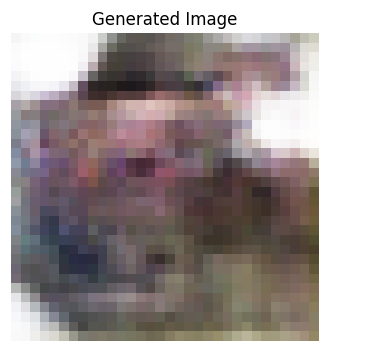

### More optimization is required :: 